<div style="background: linear-gradient(135deg, #000000 0%, #1a1a1a 100%); padding: 40px; border-radius: 15px; border-left: 5px solid #FF6B35; margin: 20px 0;">
    <h1 style="color: #FF6B35; font-family: 'Segoe UI', Arial, sans-serif; font-weight: 700; margin: 0; font-size: 2.5em;">
        🎓 Práctica 2
    </h1>
    <div style="height: 3px; background: linear-gradient(90deg, #FF6B35, #FF8C42); margin: 20px 0; border-radius: 2px;"></div>
    
<div style="margin-top: 30px; padding: 15px; background: rgba(255, 107, 53, 0.1); border-radius: 10px; border: 1px solid #FF6B35;">
    <p style="color: #ffffff; font-size: 1.3em; margin: 0; font-weight: 500;">Documentación de hallazgos de Práctica 1</p>
</div>

<div style="display: grid; grid-template-columns: 1fr 1fr; gap: 30px; margin-top: 25px;">
<div>
    <p style="color: #FF8C42; font-size: 0.9em; margin: 5px 0; font-weight: 600;">ESTUDIANTES</p>
    <p style="color: #ffffff; font-size: 1.2em; margin: 5px 0;">Bustillos Cruz Jonatan</p>
    <p style="color: #ffffff; font-size: 1.2em; margin: 5px 0;">Gutiérrez Sánchez Angélica</p>

<p style="color: #FF8C42; font-size: 0.9em; margin: 15px 0 5px 0; font-weight: 600;">MATERIA</p>
<p style="color: #ffffff; font-size: 1.2em; margin: 5px 0;">Aplicaciones de Lenguaje Natural</p>
</div>
<div>
    <p style="color: #FF8C42; font-size: 0.9em; margin: 5px 0; font-weight: 600;">PROFESORA</p>
    <p style="color: #ffffff; font-size: 1.2em; margin: 5px 0;">Elizabeth Moreno Galván</p>
    
<p style="color: #FF8C42; font-size: 0.9em; margin: 15px 0 5px 0; font-weight: 600;">FECHA</p>
<p style="color: #ffffff; font-size: 1.2em; margin: 5px 0;">Septiembre 2025</p>

<p style="color: #FF8C42; font-size: 0.9em; margin: 15px 0 5px 0; font-weight: 600;">GRUPO</p>
<p style="color: #ffffff; font-size: 1.2em; margin: 5px 0;">6BM1</p>
</div>
</div>


</div>

In [1]:
# === IMPORTACIONES Y CONFIGURACIÓN ===
# Imports estándar para Data Science y ML

# Manipulación de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Machine Learning
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc, roc_auc_score)

# Utilidades
import warnings
import os
from datetime import datetime

# Configuración de warnings
warnings.filterwarnings('ignore')

# ═══════════════════════════════════════════════════════════════
# CONFIGURACIÓN DE ESTILOS PARA VISUALIZACIONES PROFESIONALES
# ═══════════════════════════════════════════════════════════════

# Paleta de colores personalizada (negro + naranja)
custom_colors = ['#FF6B35', '#FF8C42', '#FFA45B', '#FFBB74', '#FFD28D']
sns.set_palette(custom_colors)

# Configuración de matplotlib para tema dark
plt.style.use('dark_background')
plt.rcParams['figure.facecolor'] = '#000000'
plt.rcParams['axes.facecolor'] = '#1a1a1a'
plt.rcParams['axes.edgecolor'] = '#FF6B35'
plt.rcParams['axes.labelcolor'] = '#ffffff'
plt.rcParams['text.color'] = '#ffffff'
plt.rcParams['xtick.color'] = '#cccccc'
plt.rcParams['ytick.color'] = '#cccccc'
plt.rcParams['grid.color'] = '#333333'
plt.rcParams['figure.figsize'] = (12, 7)  # Proporción cercana a golden ratio
plt.rcParams['font.size'] = 11

# Configuración de pandas para mejor visualización
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.4f}'.format)

print("✅ Configuración inicial completada")
print(f"📅 Fecha de ejecución: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")

✅ Configuración inicial completada
📅 Fecha de ejecución: 2025-09-26 04:01:59


## 📋 ÍNDICE NAVEGABLE

### 📑 Secciones Principales
1. **[Definición del problema](#-1-definición-del-problema)** - Definición de metas del proyecto
2. **[Análisis estadísitco](#a_estadistico)** - Comparativa
3. **[Análisis de Resultados](#analisis)** - Evaluación de métricas
6. **[Balanceo](#balanceo)** - Oversampling
7. **[Conclusiones](#conclusiones)** - Insights y hallazgos

<a id="def_problema"></a>
## 🎯 1. Definición del problema

<div style="background: rgba(255, 107, 53, 0.1); padding: 20px; border-radius: 10px; border-left: 4px solid #FF6B35; margin: 15px 0;">
    <p style="color: #ffffff; font-size: 1.1em; line-height: 1.6;">
        En la ESCOM como en otras universidades, tine un buzón de felicitaciones, Neutras y negativos. Sin embargo, poder extraer información útil de la misma ha sido un desafío recurrente, sbre todo por la diversidad de maneras de plantear un comentario. Lo que da lugar a comentarios sin utilidad, ya sea por no contener nada relevante o coherente o por no haber coherencia entre las respuestas del mismo cuestionario. Para poder realizar un análisis de sentimiento y poder crear herramientas futuras que resulevan esta problemática, esta práctica se centra <strong style="color: #FF6B35;">en la limpieza de los datos y el etiquetado de las clases</strong>, así como el balanceo de las mismas.
    </p>
</div>


### 1.2 Objetivos Específicos

<div class="grid-3">
    <div style="background: #1a1a1a; padding: 20px; border-radius: 8px; border-top: 3px solid #FF6B35;">
        <h4 style="color: #FF6B35;">📊 Análisis estadístico</h4>
        <ul style="color: #ffffff; line-height: 1.6;">
            <li>Etiquetar manualmente.</li>
            <li>Graficar y comparar las distribuciones.</li>
        </ul>
    </div>
    
<div style="background: #1a1a1a; padding: 20px; border-radius: 8px; border-top: 3px solid #FF8C42;">
    <h4 style="color: #FF8C42;">⚖️ Balanceo de clases</h4>
    <ul style="color: #ffffff; line-height: 1.6;">
        <li>Elegir una técnica de balanceo y justificar su uso</li>
        <li>Balancear las clases</li>
    </ul>
</div>

<a id="a_estadistico"></a>
# 📊 Análisis estadístico

## Etiquetado manual

In [ ]:
from pandas import DataFrame
from source.datos import CoordinadorDatos, VisualizadorDatos
from pathlib import Path

# Ruta genérica de los datos
PROJECT_ROOT = Path.cwd() # proyecto/source/constantes.py -> proyecto/
DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

# Cargando datos
coordinador = CoordinadorDatos()
# coordinador.visualizador.histograma('Tipo de registro')
print("Cargando datos...")
df = coordinador.obtener_dataframe()
print(df.head())

Cargando datos...
     Detalles de la queja, sugerencia o felicitación Tipo de registro
0                    funcionar computadora falta red     Felicitación
1                                          felicidad     Felicitación
2  computadora lenta siquiera conectado internet ...            Queja
3                    laboratorio excelente condición     Felicitación
4                                            apatico       Sugerencia


In [3]:
def etiquetado_manual(dataset: DataFrame) -> DataFrame:
    """
    Función para etiquetar manualmente los comentarios en el dataset.
    Asigna 1 para Negativa, 2 para Neutra y 3 para Positiva.
    """

    print("🔖 Iniciando proceso de etiquetado manual...")
    print(
        '📄 Instrucciones',
        '\n ➡️ Se te presentará un conjunto de comentarios extraídos de un buzón de Negativas, Neutras y felicitaciones.',
        '\n ➡️ Tu tarea es etiquetar cada comentario como "Negativa", "Neutra" o "Positiva".',
        '\n ➡️ Utiliza 1 para Negativa, 2 para Neutra y 3 para Positiva.'
    )

    try:
        df_etiquetado = dataset.copy()
        s_etiquetado = df_etiquetado["Detalles de la queja, sugerencia o felicitación"]

        etiquetas = [ "negativa", "neutra", "positiva" ]
        etiquetas_lista = []
        tamaño = len(s_etiquetado)

        for index, row in s_etiquetado.items():
            print(f"\nComentario {index + 1}/{tamaño}: {row}")
            while True:
                etiqueta = input(f"Ingresa la etiqueta (1: negativa, 2: neutra, 3: positiva)")
                if etiqueta in ['1', '2', '3']:
                    etiquetas_lista.append(etiquetas[int(etiqueta) - 1])
                    break
                else:
                    print("Entrada inválida. Por favor ingresa 1, 2 o 3.")

        df_etiquetado = s_etiquetado.to_frame()
        df_etiquetado['etiqueta'] = etiquetas_lista
        return df_etiquetado
    except KeyboardInterrupt:
        print("\n❌ Proceso de etiquetado manual interrumpido por el usuario.")
        return pd.DataFrame()  # Retorna un DataFrame vacío en caso de interrupción


# Etiquetado manual
df_etiquetado = etiquetado_manual(df)
df_etiquetado.head()

# Guardamos los datos
coordinador.guardar_dataframe(df_etiquetado, 'datos_etiquetados', DATA_PROCESSED)


🔖 Iniciando proceso de etiquetado manual...
📄 Instrucciones 
 ➡️ Se te presentará un conjunto de comentarios extraídos de un buzón de Negativas, Neutras y felicitaciones. 
 ➡️ Tu tarea es etiquetar cada comentario como "Negativa", "Neutra" o "Positiva". 
 ➡️ Utiliza 1 para Negativa, 2 para Neutra y 3 para Positiva.

Comentario 1/228: funcionar computadora falta red

Comentario 2/228: felicidad

Comentario 3/228: computadora lenta siquiera conectado internet estable

Comentario 4/228: laboratorio excelente condición

Comentario 5/228: apatico
Entrada inválida. Por favor ingresa 1, 2 o 3.

Comentario 6/228: servicio

Comentario 7/228: servicio

Comentario 8/228: exelente

Comentario 9/228: computadora lenta
Entrada inválida. Por favor ingresa 1, 2 o 3.

Comentario 10/228: felicidad

Comentario 11/228: ningun equipo prender

Comentario 12/228: contacto luz conectar caso traer lap
Entrada inválida. Por favor ingresa 1, 2 o 3.

Comentario 13/228: agradecer azure

Comentario 14/228: agregar 

True

## Comparación de gráficas

Usando columna automática: 'Tipo de registro'


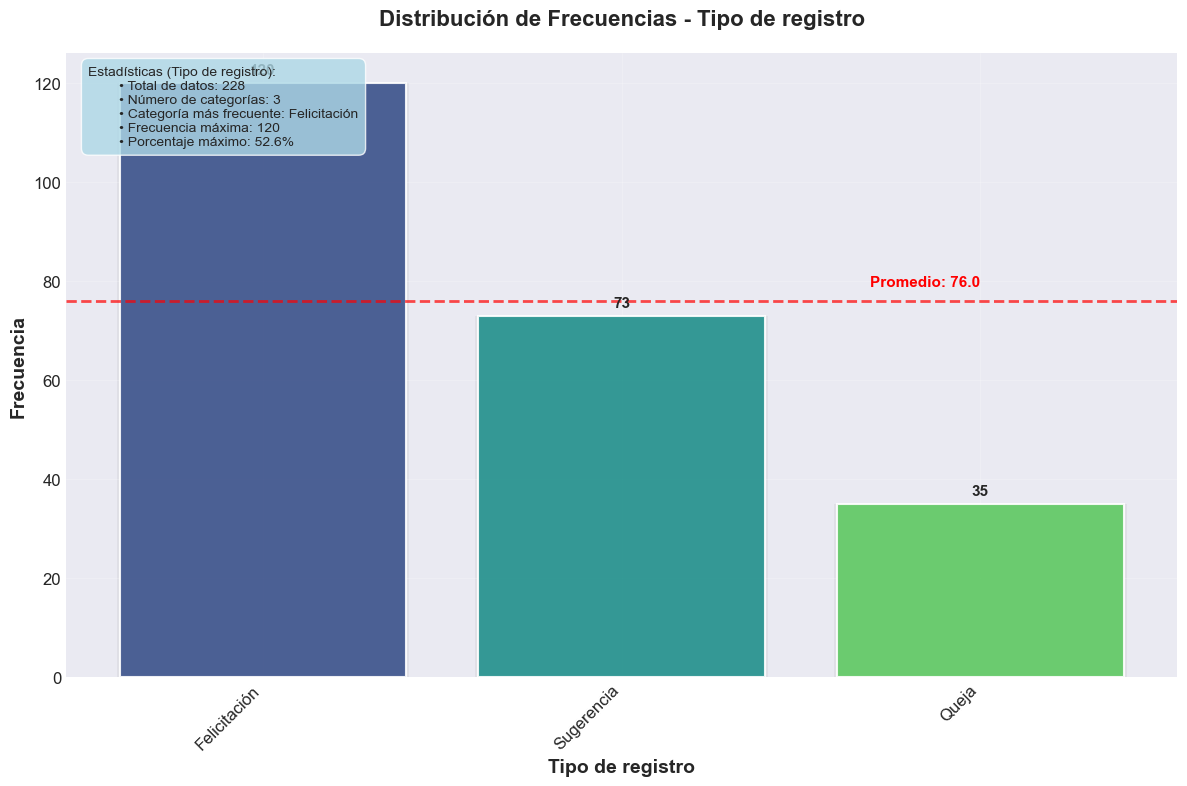


RESUMEN DE FRECUENCIAS - TIPO DE REGISTRO
Felicitación              |    120 ( 52.6%)
Sugerencia                |     73 ( 32.0%)
Queja                     |     35 ( 15.4%)
Total                     |    228 (100.0%)


In [ ]:
coordinador.visualizador.histograma()


Usando columna automática: 'etiqueta'


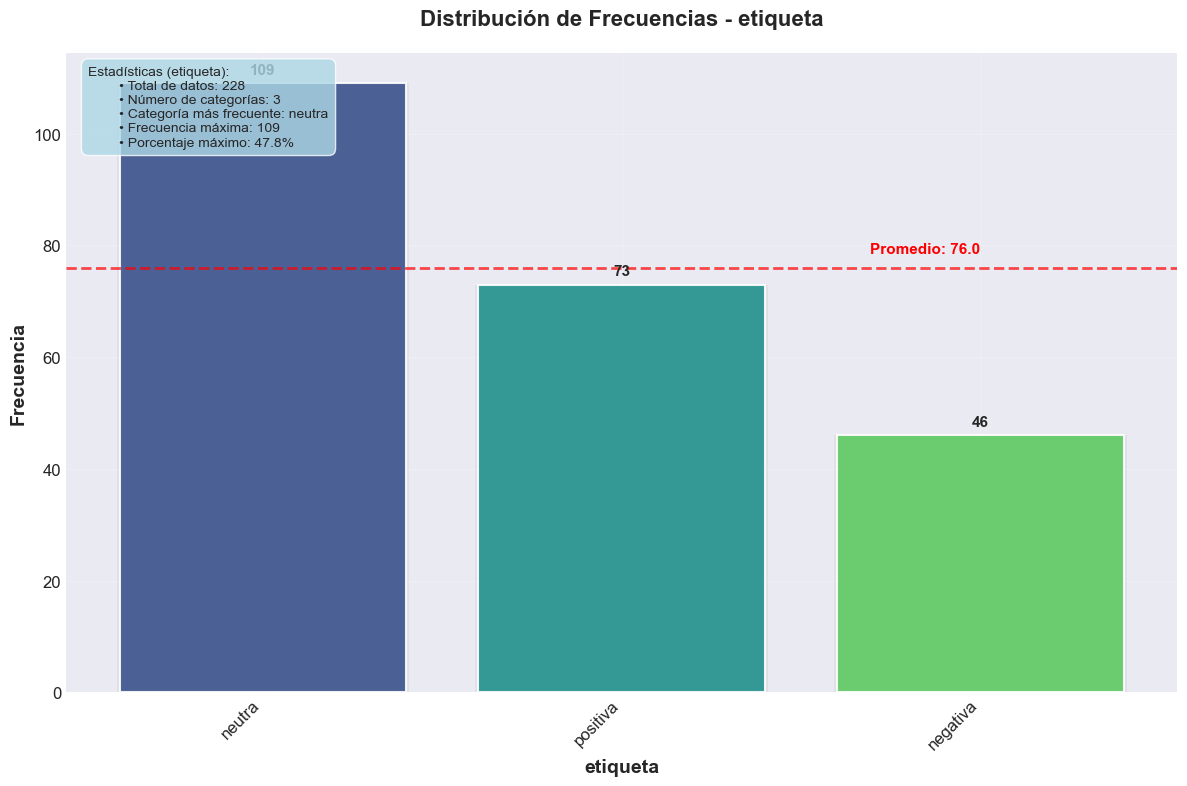


RESUMEN DE FRECUENCIAS - ETIQUETA
neutra                    |    109 ( 47.8%)
positiva                  |     73 ( 32.0%)
negativa                  |     46 ( 20.2%)
Total                     |    228 (100.0%)


In [5]:
# Cargar los datos etiquetados

coordinador.cargar_datos()
coordinador.visualizador.histograma()

<a id="analisis"></a>
# 📊 ANÁLISIS DE RESULTADOS

## Resumen de Frecuencias

| **Categoría** | **Etiquetas Originales** | **%** | **Etiquetas Manuales** | **%** |
|---------------|-------------------------|-------|------------------------|-------|
| **Positiva**  | Felicitación: 120       | 52.6% | Positiva: 73          | 32.0% |
| **Neutra**    | Sugerencia: 73          | 32.0% | Neutra: 109           | 47.8% |
| **Negativa**  | Queja: 35               | 15.4% | Negativa: 46          | 20.2% |
| **Total**     | **228**                 | **100.0%** | **228**          | **100.0%** |


## Comparación Visual por Categorías

### Distribución de Sentimientos

| Sentimiento | Original | Manual | Diferencia |
|-------------|----------|--------|------------|
| 🟢 **Positiva** | 52.6% | 32.0% | **-20.6%** |
| 🟡 **Neutra**   | 32.0% | 47.8% | **+15.8%** |
| 🔴 **Negativa** | 15.4% | 20.2% | **+4.8%**  |


## Conclusiones

### Hallazgos Principales

Una vez preprocesados, **la capacidad de distinguir entre una felicitación y un comentario neutro es mucho más difícil**, de ahí que parezca que intercambiaran números. 

### Implicaciones del Preprocesamiento

- **Pérdida de palabras clave**: Hace falta evitar que desaparezcan palabras reveladoras como:
  - `'no'`, `'sí'`, `'más'`, `'menos'`, etc.
  - Estas palabras son fundamentales para separar las neutras de las que no lo son

### Patrones Identificados

- ✅ **Mayor precisión en negativas**: Fue más habitual etiquetar correctamente las negativas e incluso encontrar más
- ⚠️ **Reclasificación de sugerencias**: Esto indica que aunque no son etiquetadas como queja, **muchas de las sugerencias podrían ser negativas**
- 📊 **Redistribución significativa**: 
  - Las felicitaciones disminuyeron del 52.6% al 32.0%
  - Los comentarios neutros aumentaron del 32.0% al 47.8%


<a id="balanceo"></a>
# 📈 Balanceo
Como los datos son muy fáciles de leer por los modelos actuales de inteligencia artificial y su precisión ha aumentado radicalmente, podremos obtener de ellos los datos faltantes de las categorías minoritarias. Es decir, la opción óptima es hacer **oversampling ayudado por la IA**.

*Nota: se utilizará Claude Sonnete en la versión 4 de septiembre del 2025*

Ejemplo de datos obtenidos:

* excelente servicio atencion rapida personal amable,positiva
* muy buen trabajo felicitar equipo profesional,positiva
* servicio calidad excepcional recomendar ampliamente,positiva
* atencion esmerada personal capacitado resolver problema,positiva
* muy satisfecho resultado obtenido muchas gracias,positiva

### Se colocan en el nuevo dataset
Los resultados generados son agregados directamente sobre la copia del archivo y la llamamos `dataset_balanceado.csv`.

Usando columna automática: 'etiqueta'


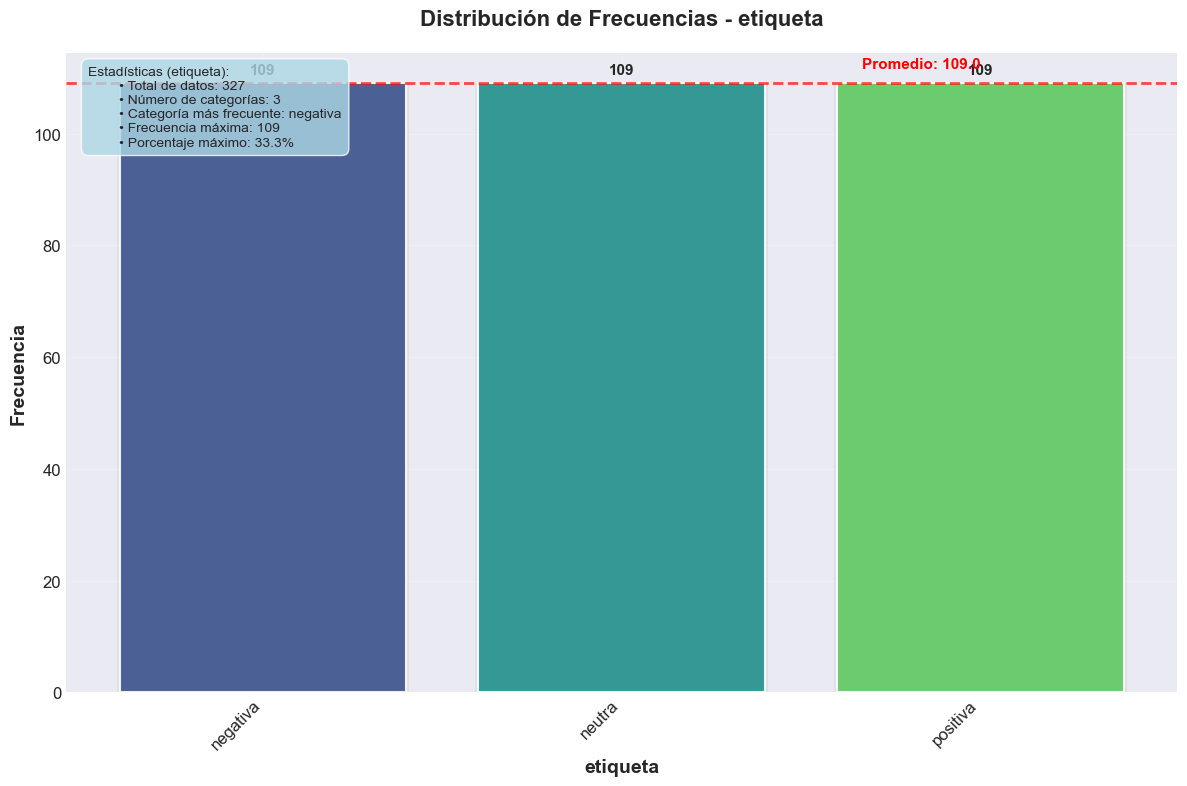


RESUMEN DE FRECUENCIAS - ETIQUETA
negativa                  |    109 ( 33.3%)
neutra                    |    109 ( 33.3%)
positiva                  |    109 ( 33.3%)
Total                     |    327 (100.0%)


In [6]:
coordinador.cargar_datos()
coordinador.visualizador.histograma()

<a id="conclusiones"></a>
# 🎯 Conclusiones
### **Principales Desafíos Encontrados**

El dataset de comentarios del buzón presentó un reto interesante: **comentarios de longitudes muy variadas**, desde respuestas de una sola palabra hasta textos largos. Esto hizo que el preprocesamiento estándar no fuera suficiente.

### **Por qué se Realizó este Preprocesamiento**

Al ser un dataset completamente nuevo, no se sabía qué esperar de los datos. Por se decidó implementar un preprocesamiento exhaustivo que incluyó:
- Limpieza básica (minúsculas, acentos, puntuación)
- Procesamiento con spaCy (tokenización, stopwords, lematización) 
- Filtros especiales para textos muy cortos o vacíos

**La razón principal fue entender realmente la naturaleza de los datos** antes de intentar cualquier modelo de clasificación.

### **Lecciones Aprendidas**

#### **1. Cada Dataset es Único**
No existe una receta universal para preprocesar texto. Este proyecto enseñó la importancia de **adaptar las técnicas a las características específicas de cada conjunto de datos**.

#### **2. En Datasets Pequeños, Cada Dato Cuenta**
Con tan pocos comentarios disponibles, se debe ser muy cuidadoso al decidir qué eliminar y qué conservar. Cada texto perdido representa información valiosa que no se puede recuperar.

#### **3. Las Stopwords Pueden Ser Importantes**
En textos cortos, palabras como "muy", "no" o "bien" pueden contener información útil para la clasificación.

### **Reflexiones Finales**
- **Conocer bien los datos es fundamental** antes de aplicar cualquier técnica
- El preprocesamiento debe adaptarse al tamaño y naturaleza del dataset
- En proyectos con datos limitados, cada decisión de limpieza tiene un impacto mayor
